# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [4]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean() * 100) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos
print(usage.isna().mean() * 100) # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- R/ En la tabla de Users los nulos son:
    - 469 en city (un 12%) y 3534 en churn_date (un 88%)
- En la tabla de Usage los nulos son:
    - 50 en date (0.12%), 22076 en duration (el 55.2%), y 17896 en length (el 44.8%)
- Indica qué harías: ¿imputar, eliminar, ignorar?
- R/ Users:
    - - City: Al ser una cantidad menor sin un patron aparente reemplazaría el valor nulo por "Privado" o "Prefiero no Decir" porque sabemos que todos tienen que pertenecer a una ciudad, pero no necesariamente tienen que responder en donde.
    - - Churn_Date: este puede estar directamente relacionado a el plan elegido o al no encontrarse en ningun plan realmente no tiene una fecha de expiración, por lo que puede ignorarse sin problema.
- Usage:
    - - Date: es una cantidad menor al 1% por lo que recomendaría ignorarse, asumirla puede generar problemas a futuro, y eliminarla significa que perderiamos el dato de una llamada que puede ser importante.
    - - Duration: Pueden quedarse registradas las llamadas perdidas, por lo que si una llamada nunca empieza no tiene una duración minima, en este caso sería mejor dejarlo como nulo para demostrar que hubo un intento de llamada pero no una llamada como tal.
     - - Length: Length solamente se está usando en los datos que tienen el tipo de texto, por lo que los nulos o que no tienen caracteres es posiblemente que sean imagenes o mensajes de voz que no tienen cadenas de texto literales, por lo que se podría ignorar y dejar como nulo o imputar luego de verificar el origen de estos mensajes

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  Identificar sentinels: valores que no deberían estar en el dataset.
    
**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
columnas_numericas_users = ["user_id", "age"]
print(users[columnas_numericas_users].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` Se ve bastante correcta, y los user_id empiezan desde 10000 y van hasta el 13999 por lo que efectivamente hay 4000 registros.
- La columna `age` Vemos valores imposibles como -999, afectando directamente el std teniendo en cuenta que es raro que haya personas con más de 100 años y el estandar está en 123.

In [14]:

# explorar columnas numéricas de usage
columnas_numericas_usage = ["id", "user_id", "duration", "length"]
print(usage[columnas_numericas_usage].describe())


                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` ambas se encuentran correctas, id se ve totalmente normal y user_id es de esperar que tenga datos similares a la tabla anterior ya que no todos los usuarios utiliza el servicio de la misma forma, ambas están correctas.
- Las columnas `duration` y `length` en estas es posible que los valores extremos en max puedan imputarse para evitar casos especificos, porque si pueden haber llamadas de 2 horas, y aunque depende del limite de caracteres si pueden existir mensajes con 1490 caracteres.

In [15]:
# explorar columnas categóricas de users
columnas_categoricas_user = ['city', 'plan']
print(users[columnas_categoricas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` aquí vemos nuevamente que faltan 469 registros en ciudad, que de nuevo podemos entender como información que el cliente desee mantener en privado y que la ciudad más popular es Bogotá.
- La columna `plan` de los 2 planes que tenemos el plan Basico cubre el 65% de nuestros usuarios.

In [16]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` es la única columna categorica de Usage, y se ve una ligera preferencia sobre el tipo Text teniendo un porcentaje del 55% del tipo de uso.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- R/ Se encontrarón valores invalidos en
    - Age de Users con valores de -999.
    - Churn_Date tenemos 3534 valores invalidos y solo 2595 personas en el plan básico, lo que significa que hay 939 personas que no tienen fecha de expiración en su plan de pago que posiblemente sea premium.
    - City nos hace falta 469 ciudades o posibles preferencias de privacidad.
- ¿Qué acción tomarías?
- R/
    - En Age valores invalidos perfectamente pueden ser imputados, los principales casos extremos son de -999 por lo que estos podrían verse remplazados por la mediana.
    - En Churn_Date es importante revisar el tipo de plan en que se encuentran, si su plan es premium debería de tener la fecha de expiración adecuada y si es básico se mantiene igual.
    - En City recomendaría reemplazar los valores invalidos por la preferencia de que sea privado 

### 2.3 Revisión y estandarización de fechas
**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')# completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [19]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date` vemos registros para los años 2022, 2023, 2024 y 40 registros para el año 2026, los cuales seguro están erroneos

In [20]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts())

2024.0    39950
Name: date, dtype: int64


En `date` en usage vemos que todos los datos excepto los nulos se encuentran en 2024. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- R/
    - El único año imposible son de 2026.
- ¿Qué harías con ellas?
- R/
    - Como es un un número muy bajo a comparación del resto de datos (solo 40 registros) estos podrían eliminarse del analisis ya que solo nos enfocaremos en 2024 luego de ver los datos de la tabla Usage donde todos sus registros validos están en ese año.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts())

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

type
call        0
text    22076
Name: duration, dtype: int64


In [25]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

R/ Efectivamente vemos que los nulos de la columna `duration` solo aparecen cuando el `type` es `text`, y de la misma manera los nulos de `length` solo aparecen cuando el `type` es `call`, por lo que sería ideal mantener estos datos como na para no editar los valores de las columnas ni modificar sus formatos.

---

## 🧩Paso 4: Summary statistics de uso por usuario

### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["total_minutes"] = usage["duration"]

# Agrupar información por usuario y aprovecho para renombrar de una vez
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text","sum"),
    cant_llamadas=("is_call","sum"),
    cant_minutos_llamada=("total_minutes","sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
print(user_profile[columnas_numericas].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.122250       5.524381       4.478120             23.317054
std      17.690408       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      47.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [29]:
# Distribución porcentual del tipo de plan
print(user_profile["plan"].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers

### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

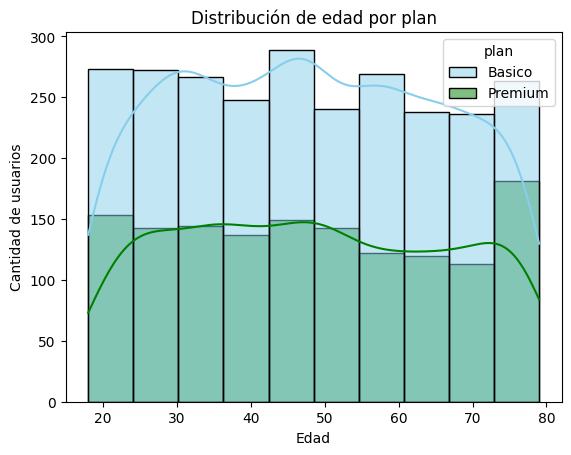

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- En general se ve una alta preferencia por el plan Basico, y quienes utilizan más el plan premium son personas entre 70 a 80 años.

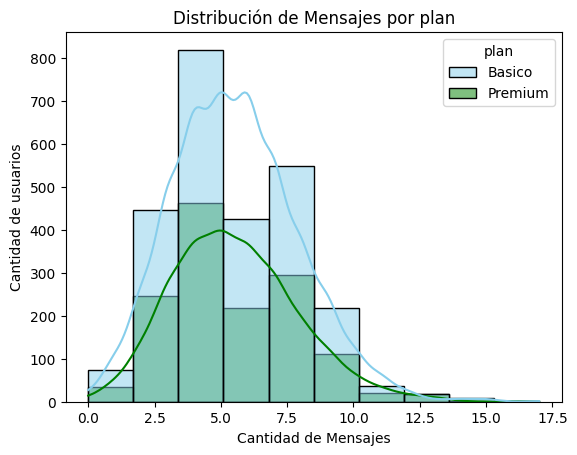

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Mensajes por plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- En promedio los usuarios envian 5 mensajes tanto en los planes premium como en los planes basicos.

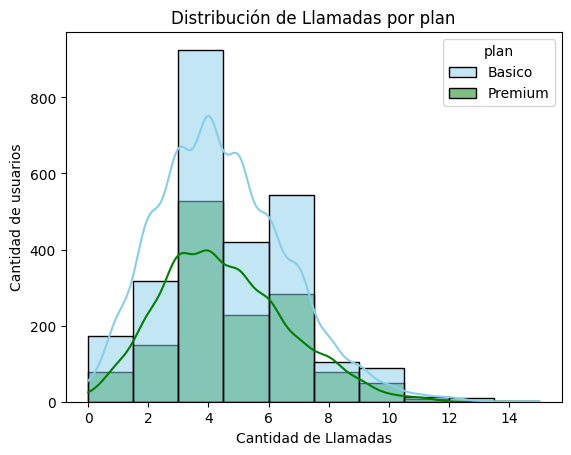

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Llamadas por plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Los usuarios no realizan tantas llamadas a comparación de mensajes.

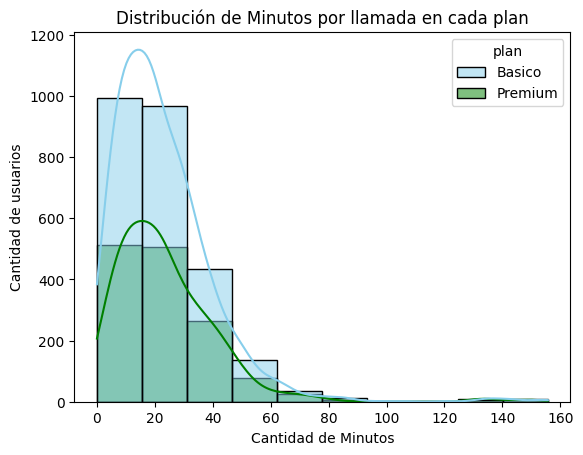

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Minutos por llamada en cada plan')
plt.xlabel('Cantidad de Minutos')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Las llamadas que duran más de una hora y media son raras y pueden ser datos imputables.

### 5.2 Identificación de Outliers

🎯**Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

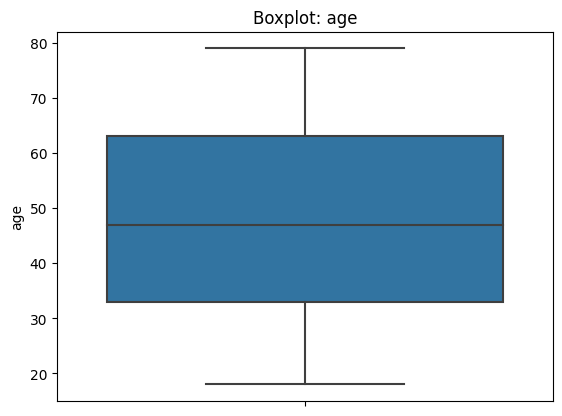

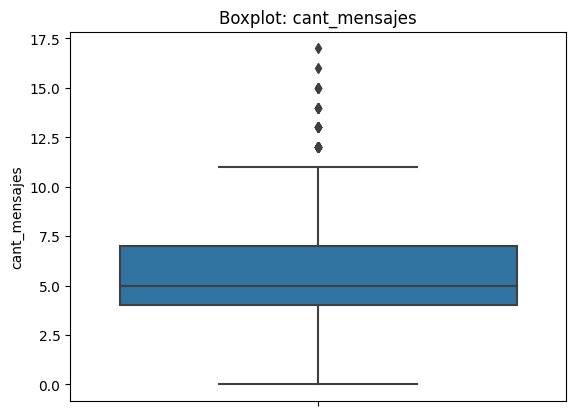

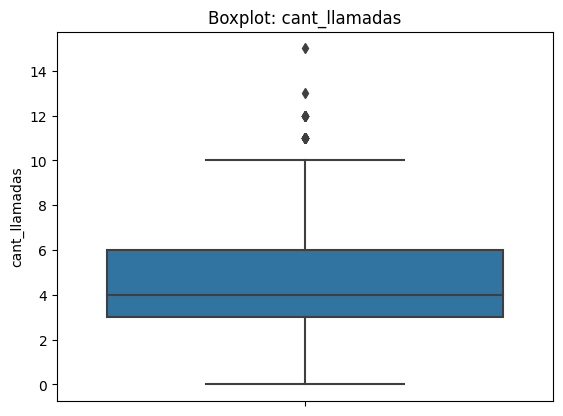

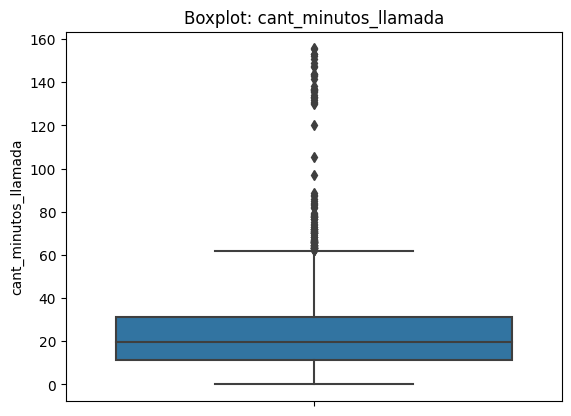

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, y=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: Luego de la limpieza que se realizó anteriormente la columna Age no presenta outliers.
- cant_mensajes: Se presentan outliers leves en los valores por encima de 10 y valores extremos con más de 15 mensajes.
- cant_llamadas: De manera similar a los mensajes, se presenta outliers leves por encima de 10 y valores extremos mayores a 15 llamadas.
- cant_minutos_llamada: Se evidencian muchos outliers fuera del cuartil extremo superior.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col} → límite inferior: {limite_inferior:.2f} | límite superior: {limite_superior:.2f}")

age → límite inferior: -12.00 | límite superior: 108.00
cant_mensajes → límite inferior: -0.50 | límite superior: 11.50
cant_llamadas → límite inferior: -1.50 | límite superior: 10.50
cant_minutos_llamada → límite inferior: -19.32 | límite superior: 61.86


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 

Se decide mantener los outliers en el dataset ya que representan comportamientos reales de usuarios y no errores de captura. Sin embargo, se tendrán en cuenta como excepciones al interpretar promedios o distribuciones generales.

---

## 🧩Paso 6: Segmentación de Clientes
### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Definir condiciones
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

resultados = ['Bajo uso','Uso medio']

# Crear la columna
user_profile['grupo_uso'] = np.select(condiciones, resultados, default='Alto uso')

In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.
**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

# Definir resultados para cada condición
resultados_edad = ['Joven', 'Adulto']

# Crear la columna
user_profile['grupo_edad'] = np.select(condiciones_edad, resultados_edad, default='Adulto Mayor')

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

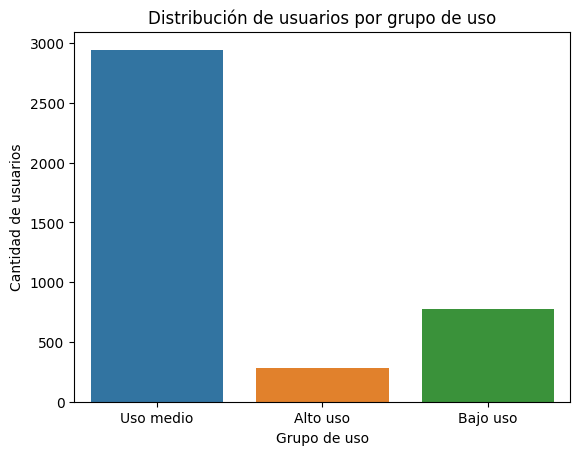

In [41]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

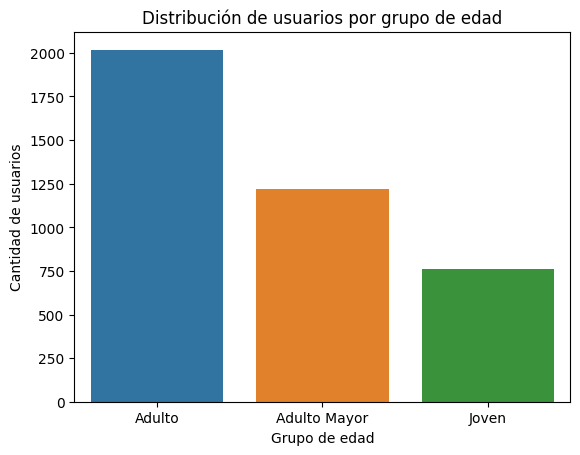

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Los problemas iniciales detectados fueron diversos valores nulos o invalidos en edades, ciudades, fechas, duration, y length, donde algunos tenian sentinels o directamente datos imposibles. De manera precisa:
    - Age: se encontraron 2 registros de edades de -999 lo cual es un valor imposible.
    - City: habían 469 valores invalidos, el 12%.
    - Churn_Date: esta columna tiene el 88% de valores nulos, principalmente porque la mayoría de planes basicos no expiran, sin problemas.
    - Duration y Length: el problema inicial es que ambas columnas tenian valores nulos estructurales esperados porque dependian de que tipo de mensaje se realizaba, si era llamada Length aparecería nulo y si era texto Duration aparecería nulo, por lo que no eran errores.
    - Date: las fechas que marcaban años de 2026 fueron eliminadas del analisis.


🔍 **Segmentos por Edad**

Dividiendo a los usuarios en tres grupos de edad (Joven, Adulto y Adulto Mayor), se identificó que los Adultos (30-60 años) son el segmento más activo en general, liderando en la suma de llamadas y mensajes. Los Adultos Mayores presentan un patrón diferenciado: mayor preferencia por llamadas y menor uso de mensajes de texto, lo que sugiere un perfil más tradicional de comunicación. Los Jóvenes (menores de 30 años) son el segmento de menor uso, e igualmente utilizan un poco más de mensajes que los adultos mayores.


📊 **Segmentos por Nivel de Uso**

Para maximizar los ingresos, ConnectaTel debería priorizar dos segmentos clave. Por un lado, los Adultos representan el grupo de edad con mayor cantidad de usuarios Premium (693), lo que los convierte en el segmento más valioso para estrategias de retención. Por otro lado, los usuarios de Uso Medio presentan una oportunidad de conversión interesante: con 1,897 usuarios Básico frente a 1,046 Premium, existe un margen significativo para migrarlos al plan Premium, siempre que la oferta demuestre un beneficio tangible en su uso diario.


**Patrones de uso Extremo (outliers)**

Se detectaron outliers en cant_mensajes, cant_llamadas y cant_minutos_llamada, todos por encima del límite superior calculado con el método IQR. Estos no fueron eliminados ya que representan comportamientos reales de usuarios con uso intensivo del servicio. Para el negocio, estos usuarios son candidatos ideales para migrar del plan Básico al Premium, ya que su nivel de consumo sugiere que podrían apreciar y rentabilizar mejor los beneficios de un plan superior.


💡 **Recomendaciones**

1. Usuarios de Uso Medio en plan Básico: Ofrecer bundles que combinen el plan de telefonía con servicios de streaming como Disney+ o Win Sports, siguiendo el modelo exitoso de operadores como Tigo en Colombia. Esto agrega valor percibido sin necesariamente reducir el precio.
2. Adultos Mayores: Diseñar un plan Premium enfocado en llamadas, donde el costo por minuto disminuya a mayor duración. Esto se alinea directamente con su patrón de uso e incentiva la migración al plan superior.
3. Jóvenes: Crear planes estudiantiles con tarifas preferenciales e incluir servicios de música en streaming como Spotify o YouTube Music, integrándose a su estilo de vida digital diario.
4. Usuarios de Alto Uso (outliers): Aplicar la misma estrategia de llamadas escalonadas del punto 2, ya que el ahorro económico puede fidelizarlos y convertirlos en promotores orgánicos de la marca.

In [45]:
# Ver los usuarios con uso extremo
print(user_profile[user_profile['grupo_uso'] == 'Alto uso'][['cant_llamadas', 'cant_mensajes', 'cant_minutos_llamada', 'plan']].describe())

       cant_llamadas  cant_mensajes  cant_minutos_llamada
count     278.000000     278.000000            278.000000
mean        5.946043       9.561151             30.149784
std         3.257976       2.813364             20.960601
min         0.000000       0.000000              0.000000
25%         3.000000      10.000000             13.557500
50%         5.000000      10.000000             25.930000
75%         9.750000      11.000000             42.715000
max        15.000000      17.000000            130.230000


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---
Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/czapata-data-projects/telecom-data-analysis/tree/main